# Classification Track — Part A — Google Play Store Apps Dataset
**23CSE301 Machine Learning — Capstone Project — Review 1**

Dataset: [Google Play Store Apps (Kaggle)](https://www.kaggle.com/datasets/yusufdelikkaya/google-play-store-apps-dataset)

Review 1 : Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM. 


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 100

In [7]:
DATA_PATH = "../data/playstore_apps.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Describe: ", df.describe)
print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.head()


Shape: (10841, 13)
Describe:  <bound method NDFrame.describe of                                                      App             Category  \
0         Photo Editor & Candy Camera & Grid & ScrapBook       ART_AND_DESIGN   
1                                    Coloring book moana       ART_AND_DESIGN   
2      U Launcher Lite – FREE Live Cool Themes, Hide ...       ART_AND_DESIGN   
3                                  Sketch - Draw & Paint       ART_AND_DESIGN   
4                  Pixel Draw - Number Art Coloring Book       ART_AND_DESIGN   
...                                                  ...                  ...   
10836                                   Sya9a Maroc - FR               FAMILY   
10837                   Fr. Mike Schmitz Audio Teachings               FAMILY   
10838                             Parkinson Exercices FR              MEDICAL   
10839                      The SCP Foundation DB fr nn5n  BOOKS_AND_REFERENCE   
10840      iHoroscope - 2018 Daily Horoscope 

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [8]:
# ── Convert object columns that contain numeric information ───────────

# Reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# Installs: "10,000+" → 10000
df["Installs"] = (
    df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Price: "$4.99" → 4.99
df["Price"] = (
    df["Price"]
    .str.replace("$", "", regex=False)
)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Size: convert everything to MB
def convert_size(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x == "Varies with device":
        return np.nan

    if x.endswith("M"):
        return float(x[:-1])

    if x.endswith("k"):
        return float(x[:-1]) / 1024

    return np.nan

df["Size"] = df["Size"].apply(convert_size)

print("\nUpdated dtypes:")
print(df.dtypes)


Updated dtypes:
App                object
Category           object
Rating            float64
Reviews           float64
Size              float64
Installs          float64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


In [9]:
RATING_COL = "Rating" 

df = df.dropna(subset=[RATING_COL])
median_rating = df[RATING_COL].median()
df["target_class"] = np.where(df[RATING_COL] >= median_rating, "High", "Low")
TARGET_COLUMN = "target_class"

print(df[TARGET_COLUMN].value_counts())
print("\nClass balance:\n", df[TARGET_COLUMN].value_counts(normalize=True))


target_class
High    5141
Low     4226
Name: count, dtype: int64

Class balance:
 target_class
High    0.548842
Low     0.451158
Name: proportion, dtype: float64


**EDA**

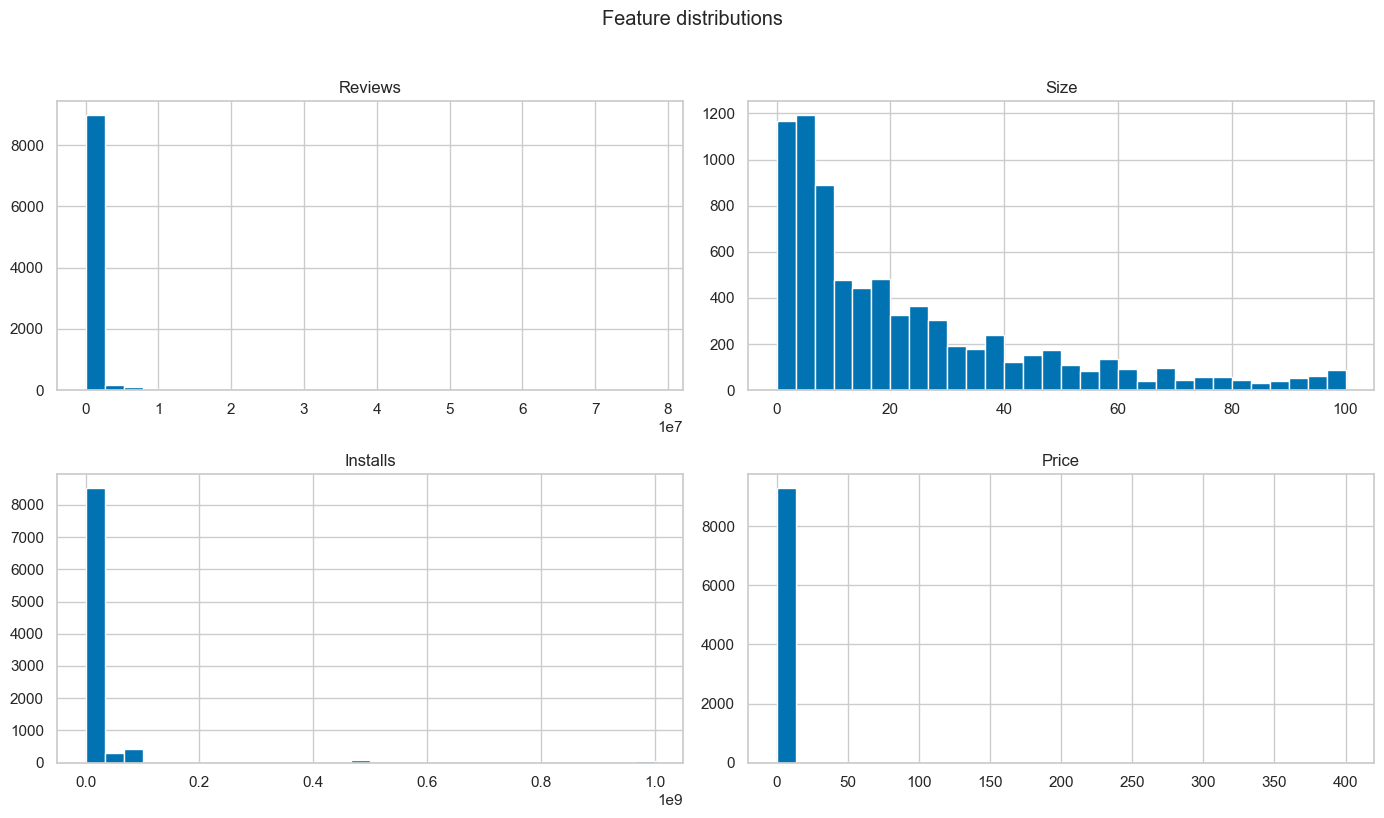

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != RATING_COL]  

df[num_cols].hist(bins=30, figsize=(14, 8))
plt.suptitle("Feature distributions", y=1.02)
plt.tight_layout()
plt.savefig("../models/clf_eda_distributions.png", bbox_inches="tight")
plt.show()

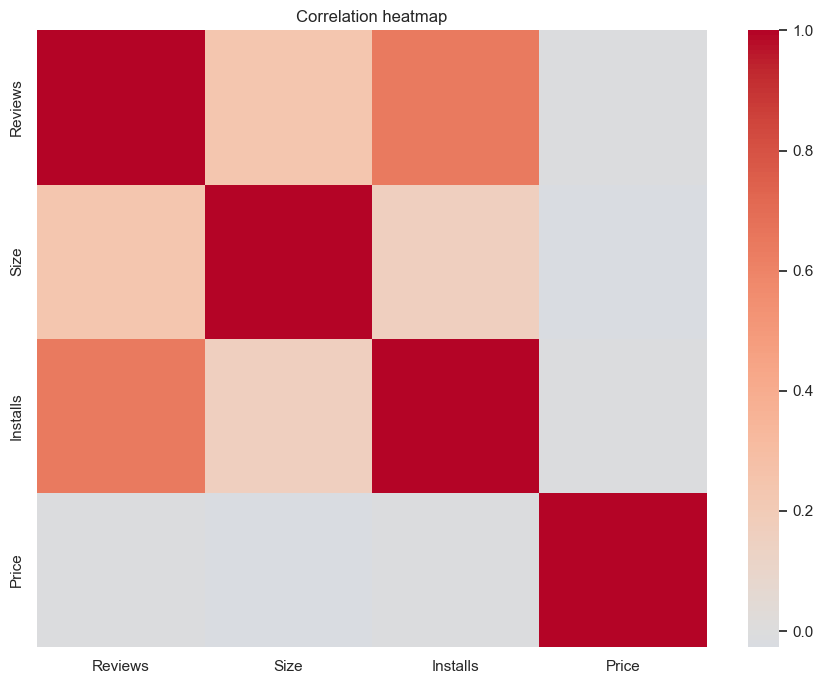

In [11]:
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig("../models/clf_eda_correlation.png", bbox_inches="tight")
plt.show()


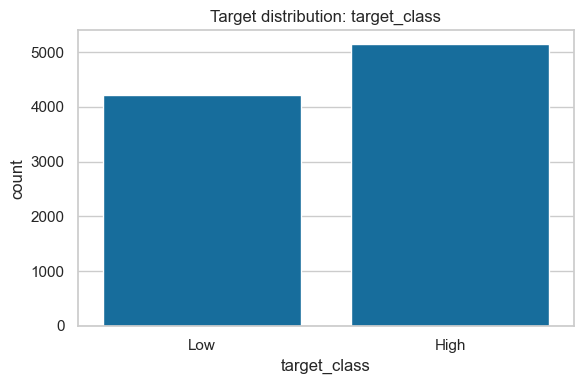

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COLUMN)
plt.title(f"Target distribution: {TARGET_COLUMN}")
plt.tight_layout()
plt.savefig("../models/clf_eda_target_dist.png", bbox_inches="tight")
plt.show()


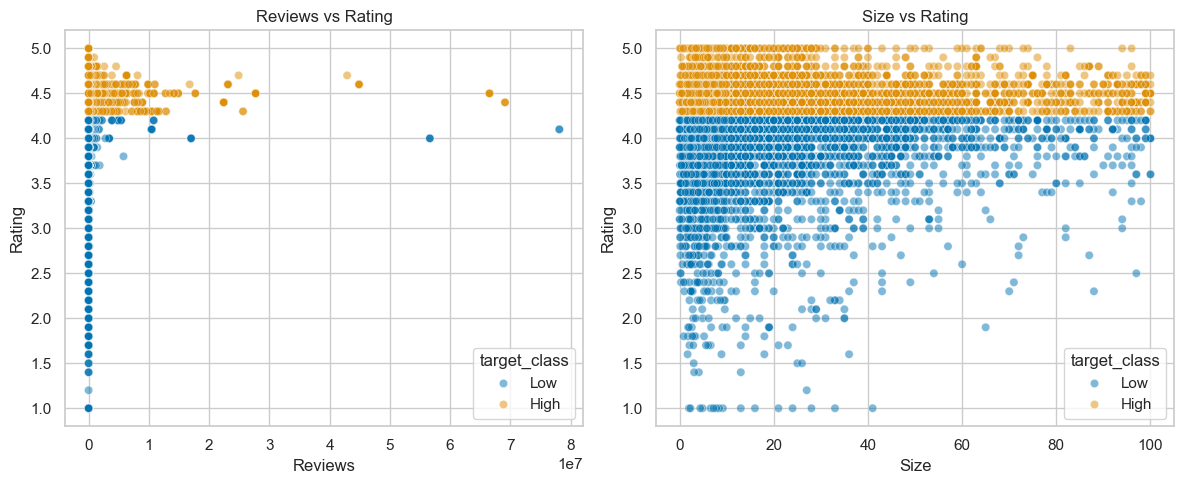

In [13]:
# At least two scatter plots: feature vs a numeric proxy, coloured by class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, feat in zip(axes, num_cols[:2]):
    sns.scatterplot(data=df, x=feat, y=RATING_COL, hue=TARGET_COLUMN, alpha=0.5, ax=ax)
    ax.set_title(f"{feat} vs {RATING_COL}")
plt.tight_layout()
plt.savefig("../models/clf_eda_scatter.png", bbox_inches="tight")
plt.show()


**Handling missing values, duplicates, outliers** 

In [14]:
cat_cols = [c for c in df.select_dtypes(exclude=[np.number]).columns if c != TARGET_COLUMN]

for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

assert df[num_cols + [TARGET_COLUMN]].isnull().sum().sum() == 0, "Still missing values in key columns"

Dropped 474 duplicate rows


In [15]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for c in num_cols:
    lo, hi = iqr_bounds(df[c])
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    if n_out > 0:
        df[c] = df[c].clip(lo, hi)
        print(f"{c}: capped {n_out} outliers")


Reviews: capped 1555 outliers
Size: capped 737 outliers
Installs: capped 751 outliers
Price: capped 613 outliers


Capping at 1.5×IQR (rather than dropping) keeps genuinely popular apps in the sample while limiting their leverage on distance-based models like KNN/SVM.

**Feature Engineering**


In [16]:
skew_candidate = [c for c in num_cols if df[c].min() >= 0][0] if num_cols else None
if skew_candidate:
    df[f"log_{skew_candidate}"] = np.log1p(df[skew_candidate])
    print(f"Engineered feature added: log_{skew_candidate}")


Engineered feature added: log_Reviews


**Encoding, scaling, stratified split**

In [17]:
feature_cols = [c for c in df.columns if c not in [TARGET_COLUMN, RATING_COL]]
non_numeric_cols = set(df.select_dtypes(exclude=[np.number]).columns)
cat_feature_cols = [c for c in feature_cols if c in non_numeric_cols]
num_feature_cols = [c for c in feature_cols if c not in cat_feature_cols]

# One-hot encode categoricals with low-to-moderate cardinality; drop very high-cardinality
# free-text-like columns (App name) which don't generalise as categorical features.
cat_feature_cols = [c for c in cat_feature_cols if df[c].nunique() <= 50]
df_model = df[num_feature_cols + cat_feature_cols + [TARGET_COLUMN]].copy()
df_model = pd.get_dummies(df_model, columns=cat_feature_cols, drop_first=True)

le = LabelEncoder()
X = df_model.drop(columns=[TARGET_COLUMN])
y = le.fit_transform(df_model[TARGET_COLUMN])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)
print("Classes:", dict(zip(le.classes_, range(len(le.classes_)))))


Train: (7114, 75) Test: (1779, 75)
Classes: {'High': 0, 'Low': 1}


**Algorithms and their evaluation**

In [18]:
clf_results = []
all_classification_models = {}   # name -> fitted model, saved so the GUI can query any of them

def evaluate_clf(name, model, X_tr, X_te, y_tr, y_te, labels):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    acc = accuracy_score(y_te, pred)
    f1 = f1_score(y_te, pred, average="weighted")
    clf_results.append({"Model": name, "Accuracy": acc, "F1 (weighted)": f1})
    all_classification_models[name] = model
    print(f"{name:22s} Accuracy={acc:.4f}  F1(weighted)={f1:.4f}")

    cm = confusion_matrix(y_te, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"Confusion matrix — {name}")
    plt.tight_layout()
    plt.savefig(f"../models/clf_cm_{name.replace(' ', '_')}.png", bbox_inches="tight")
    plt.show()
    return model


Logistic regression

Logistic Regression    Accuracy=0.6251  F1(weighted)=0.6254


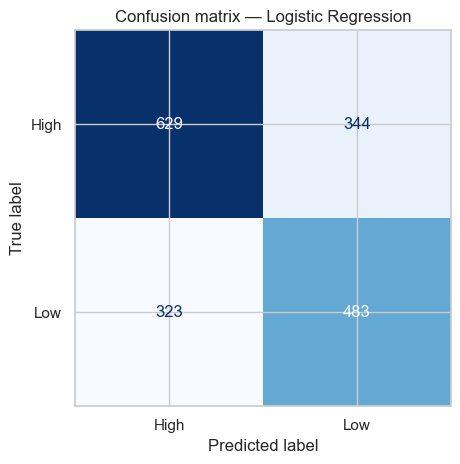

In [19]:
logreg = evaluate_clf("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                       X_train_scaled, X_test_scaled, y_train, y_test, le.classes_)
